In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from PIL import Image
import albumentations as A
import cv2
from matplotlib import pyplot as plt

In [3]:
KEYPOINT_COLOR = (0, 255, 0) # Green

def vis_keypoints(im, keypoints, color=KEYPOINT_COLOR, diameter=5):
    im = im.copy()

    for (x, y) in keypoints:
        cv2.circle(im, (int(x), int(y)), diameter, color, -1)

    # plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.imshow(im)

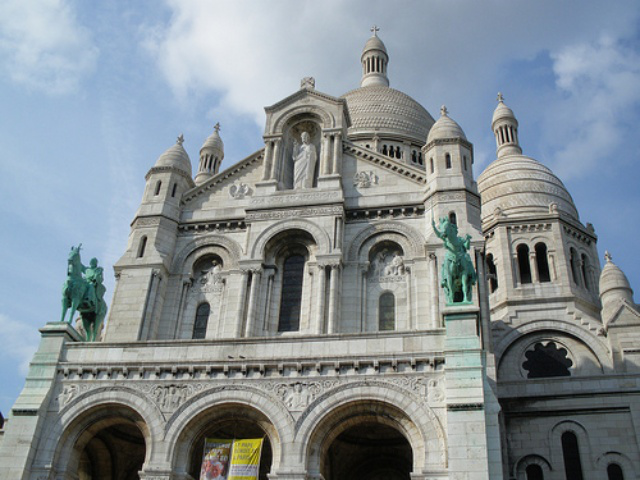

In [4]:
image = Image.open('../data/sacre_coeur_A.jpg')
image

Image Size : (640, 480)
image_np Shape : (480, 640, 3)


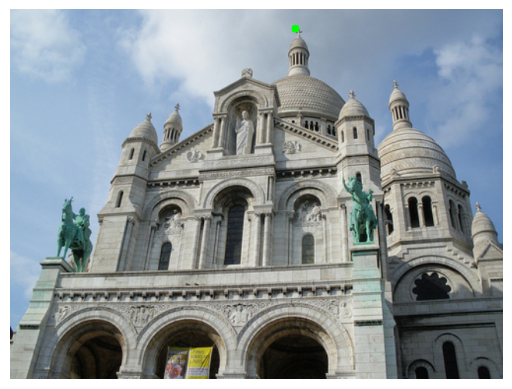

In [5]:
keypoint = (x, y) = (370, 25) # (x, y) horizontal, vertical

width, height = image.size
print(f'Image Size : {width, height}')

patch_size = 128
patch_size_half = patch_size // 2

image_np = np.array(image)
print(f'image_np Shape : {image_np.shape}')

keypoints = [keypoint]
vis_keypoints(image_np, keypoints)

306 434 0 128
[[64.0, 25.0]]


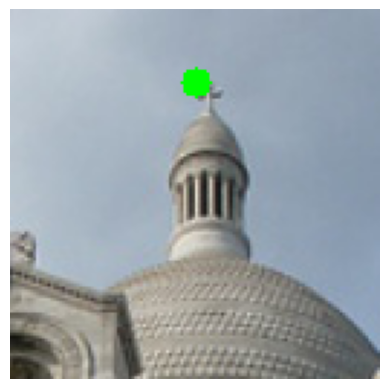

In [6]:
left, right = x - patch_size_half, x + patch_size_half
upper, lower = y - patch_size_half, y + patch_size_half

if left < 0:
    right += -left
    left = 0
elif right > width:
    left -= right - width
    right = width

if upper < 0:
    lower += -upper
    upper = 0
elif lower > height:
    upper -= lower - height
    lower = height
    
print(left, right, upper, lower)
    
transform = A.Compose(
    transforms=[
        A.Crop(
            x_min=left, y_min=upper, 
            x_max=right, y_max=lower
        ),
    ], 
    keypoint_params=A.KeypointParams(format='xy')
)

transformed = transform(image=image_np, keypoints=keypoints)

transformed_image = transformed['image']
transformed_keypoints = transformed['keypoints']
print(transformed_keypoints)

vis_keypoints(transformed_image, transformed_keypoints)

In [7]:
transformed_image

array([[[192, 200, 211],
        [195, 203, 214],
        [196, 204, 215],
        ...,
        [147, 163, 179],
        [147, 162, 181],
        [146, 162, 178]],

       [[193, 201, 212],
        [195, 203, 214],
        [195, 203, 214],
        ...,
        [146, 162, 178],
        [146, 161, 180],
        [146, 161, 180]],

       [[194, 202, 213],
        [195, 203, 214],
        [195, 203, 214],
        ...,
        [145, 161, 177],
        [145, 160, 179],
        [145, 160, 179]],

       ...,

       [[ 60,  53,  34],
        [ 56,  51,  31],
        [ 52,  47,  28],
        ...,
        [ 81,  83,  82],
        [119, 120, 124],
        [177, 177, 175]],

       [[ 58,  51,  33],
        [ 57,  50,  34],
        [ 55,  49,  33],
        ...,
        [ 98,  98,  98],
        [147, 143, 132],
        [210, 206, 194]],

       [[ 53,  46,  30],
        [ 54,  46,  33],
        [ 63,  57,  43],
        ...,
        [123, 121, 122],
        [185, 174, 154],
        [205, 197, 178]]

[[401.1467590332031, 22.066110610961914]]


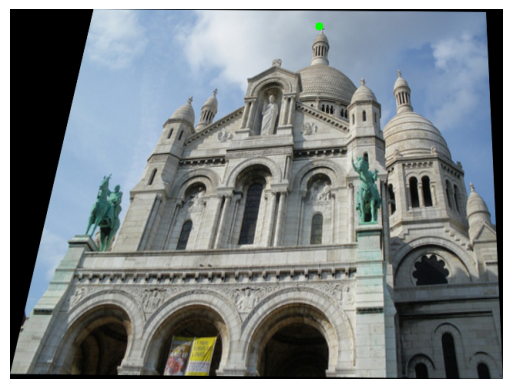

In [8]:
transform = A.Compose(
    transforms=[
        A.Perspective(keep_size=True, fit_output=True, p=1)
    ], 
    keypoint_params=A.KeypointParams(format='xy')
)

transformed = transform(image=image_np, keypoints=keypoints)

transformed_image = transformed['image']
transformed_keypoints = transformed['keypoints']
print(transformed_keypoints)

vis_keypoints(transformed_image, transformed_keypoints)

In [9]:
transformed_keypoints

[[401.1467590332031, 22.066110610961914]]